# Nonlinear Feature Encoding Phase Diagram

Exploring when autoencoders learn nonlinear vs linear encodings as a function of:
- **n**: number of input features
- **m**: bottleneck dimension  
- **l**: number of linear layers in encoder (l=1 is linear encoder, l≥2 is nonlinear)
- **S**: sparsity = probability of being ZERO (S=0.9 means 10% active)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

# Import core functions from shared module
# (Also used by toy_models_sanity_check.ipynb to verify correctness)
from core import (
    Autoencoder,
    generate_sparse_data,
    generate_correlated_features,
    train_autoencoder,
    measure_encoding_linearity,
    compute_jacobian_stats,
    run_experiment,
    run_phase_sweep,
    device
)

print(f"Using device: {device}")

Using device: cpu


## Autoencoder Architecture

Structure: `n -> [n]*l -> m -> [n]*l -> n` (2l+1 total layers)

## Data Generation

Generate sparse feature vectors. Each sample has only a fraction of features active.

## Training

## Measuring Linearity of Encoding

Key question: Is the encoder behaving linearly or nonlinearly?

Approaches:
1. **Linear probe comparison**: How well does a linear encoder (fit post-hoc) approximate the learned encoding?
2. **Jacobian rank**: What's the effective rank of the encoder's Jacobian?
3. **Superposition metric**: Are more than m features represented in the bottleneck?

## Single Experiment

In [ ]:
# Test single experiment
# Note: S = probability of being ZERO (S=0.9 means 10% active)
results = run_experiment(n=64, m=8, l=3, S=0.9)

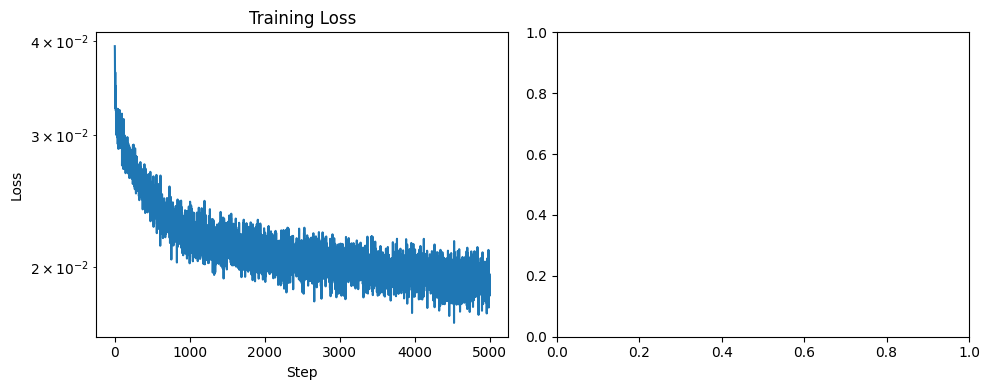

In [21]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(results['losses'])
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.yscale('log')

plt.subplot(1, 2, 2)
# Visualize encoder weights if l=1 (simple case)
if results['l'] == 1:
    W = list(results['model'].encoder.parameters())[0].detach().cpu().numpy()
    plt.imshow(W, aspect='auto', cmap='RdBu')
    plt.colorbar()
    plt.title('First Encoder Layer Weights')
plt.tight_layout()
plt.show()

## Phase Diagram Sweep

In [ ]:
# Run a sweep (adjust ranges as needed - this can take a while)
# Note: S = probability of being ZERO (S=0.9 means 10% active)
sweep_results = run_phase_sweep(
    n_values=[32, 64, 128],
    m_values=[4, 8, 16, 32],
    l_values=[1, 2, 3, 4],
    S=0.9,
    n_steps=3000
)

In [23]:
df = pd.DataFrame(sweep_results)
df['compression_ratio'] = df['n'] / df['m']
df.head(10)

,n,m,l,sparsity,importance_decay,final_loss,linearity_score,mse_full,mse_linear,nonlinear_gain,jacobian_variance,effective_rank,compression_ratio
0,32,4,1,0.1,None,0.019639,0.948088,0.019705,0.021578,0.086780,0.057046,3.920745,8.0
1,32,4,2,0.1,None,0.018412,0.933215,0.018724,0.021191,0.116406,0.123991,3.935371,8.0
2,32,4,3,0.1,None,0.018471,0.934016,0.018801,0.020994,0.104473,0.396669,3.875123,8.0
3,32,4,4,0.1,None,0.020403,0.961123,0.020797,0.022799,0.087824,0.680013,3.338954,8.0
4,32,8,1,0.1,None,0.012533,0.975968,0.011883,0.013623,0.127718,0.026890,7.823500,4.0
5,32,8,2,0.1,None,0.012218,0.957367,0.011934,0.013725,0.130532,0.103100,7.645824,4.0
6,32,8,3,0.1,None,0.016036,0.973174,0.016163,0.017046,0.051770,0.058933,7.066824,4.0
7,32,8,4,0.1,None,0.018999,0.945512,0.018810,0.021043,0.106100,0.145503,3.834617,4.0
8,32,16,1,0.1,None,0.008624,0.999659,0.009283,0.009284,0.000078,0.000385,14.380828,2.0
9,32,16,2,0.1,None,0.006447,0.997435,0.006571,0.006771,0.029509,0.005558,13.298234,2.0


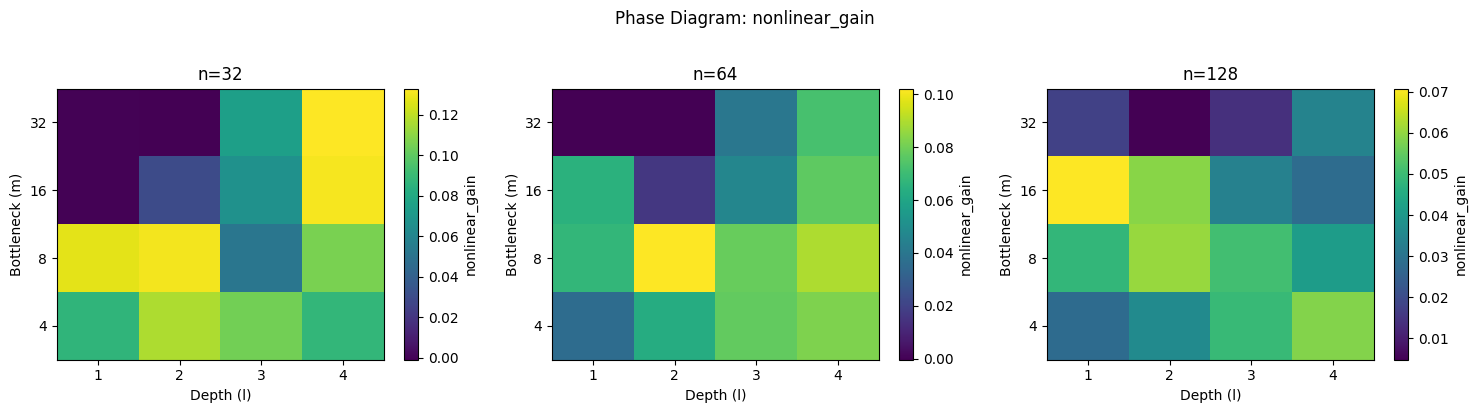

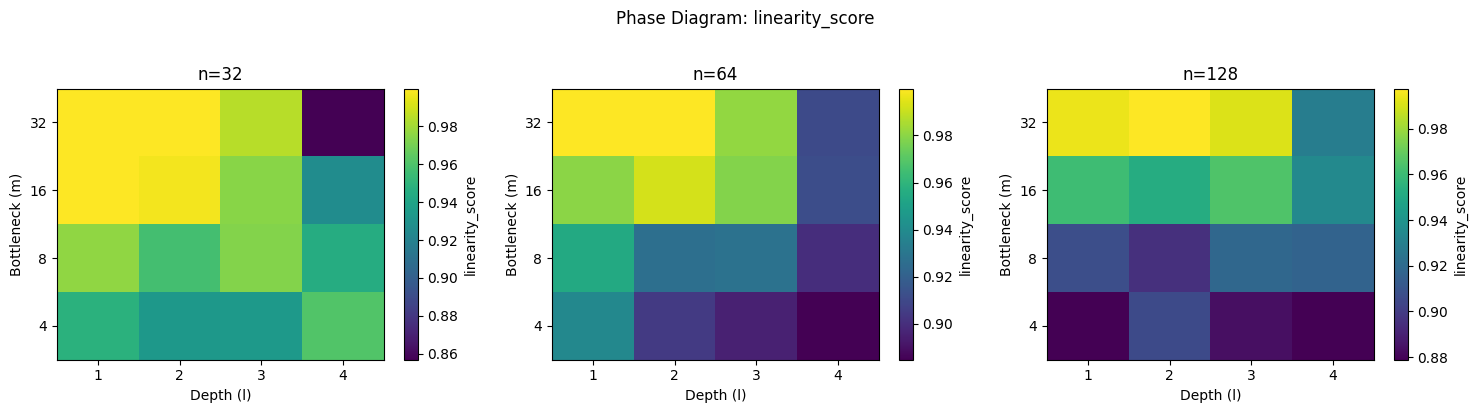

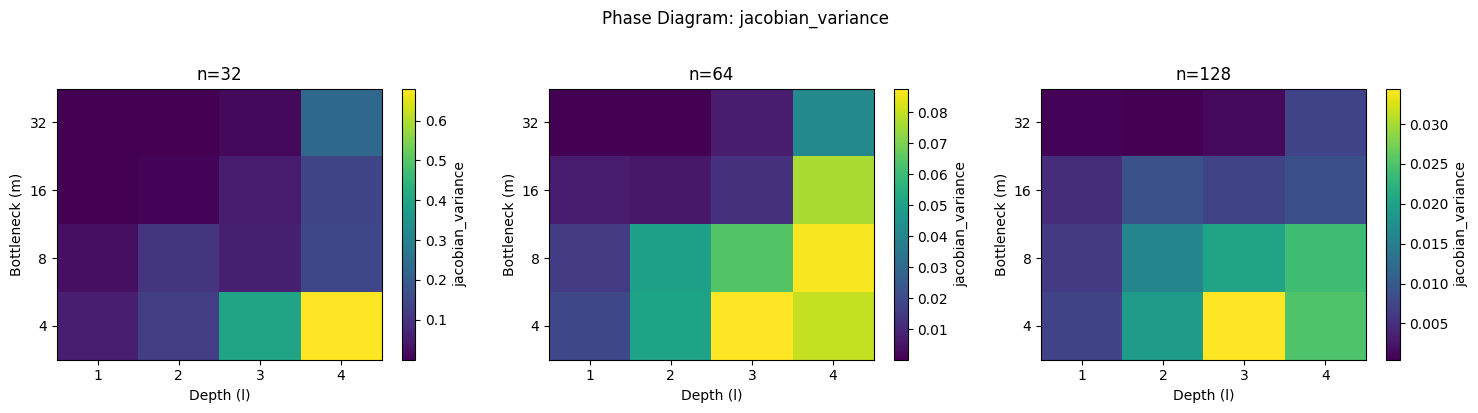

In [24]:
def plot_phase_diagram(df: pd.DataFrame, metric: str = 'nonlinear_gain'):
    """Plot phase diagrams for the sweep results."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Plot 1: m vs l for each n
    for i, n in enumerate(df['n'].unique()):
        ax = axes[i]
        subset = df[df['n'] == n]
        pivot = subset.pivot(index='m', columns='l', values=metric)
        im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', origin='lower')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel('Depth (l)')
        ax.set_ylabel('Bottleneck (m)')
        ax.set_title(f'n={n}')
        plt.colorbar(im, ax=ax, label=metric)
    
    plt.suptitle(f'Phase Diagram: {metric}', y=1.02)
    plt.tight_layout()
    plt.show()

plot_phase_diagram(df, 'nonlinear_gain')
plot_phase_diagram(df, 'linearity_score')
plot_phase_diagram(df, 'jacobian_variance')

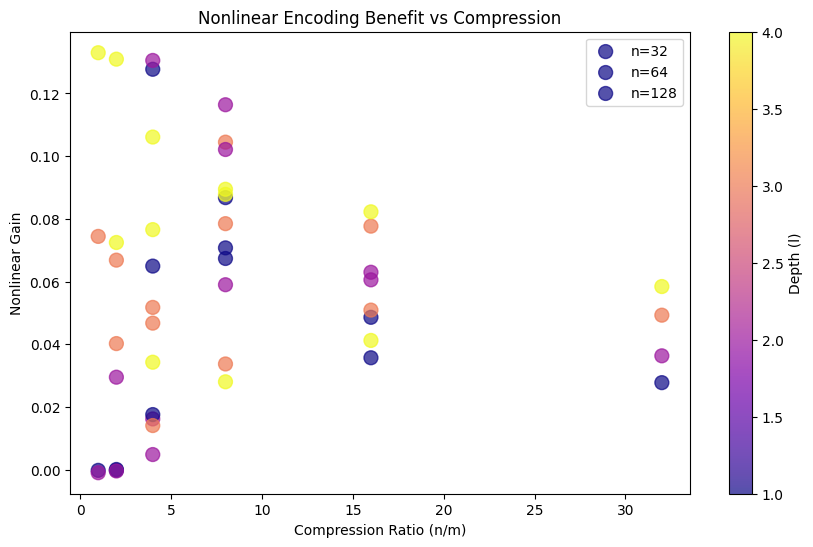

In [25]:
# Alternative view: compression ratio vs depth
plt.figure(figsize=(10, 6))

for n in df['n'].unique():
    subset = df[df['n'] == n]
    plt.scatter(subset['compression_ratio'], subset['nonlinear_gain'], 
                c=subset['l'], cmap='plasma', s=100, alpha=0.7, 
                label=f'n={n}')

plt.colorbar(label='Depth (l)')
plt.xlabel('Compression Ratio (n/m)')
plt.ylabel('Nonlinear Gain')
plt.title('Nonlinear Encoding Benefit vs Compression')
plt.legend()
plt.show()

## Analysis: Where Do LLMs Fall?

Rough estimates for modern LLMs:
- **n** (feature dimension): ~10^4 - 10^5 (residual stream dimension × sequence length)
- **m** (effective bottleneck): This is the interesting question - it's implicit in how information flows
- **l** (depth): ~32-100 layers, so effectively very deep

The hypothesis: LLMs likely operate in the highly nonlinear regime because:
1. Very high n (lots of features to represent)
2. Implicit compression (attention bottleneck, finite context)
3. Very deep (lots of layers for nonlinear computation)

In [26]:
# Extrapolate to LLM-scale (rough estimates)
# We can't actually run these, but we can visualize where they'd fall on our diagram

llm_estimates = {
    'GPT-2 small': {'n': 768, 'm': 64, 'l': 12},  # very rough
    'GPT-3': {'n': 12288, 'm': 256, 'l': 96},
    'Claude-scale': {'n': 8192, 'm': 128, 'l': 80},
}

print("LLM Compression Ratios:")
for name, params in llm_estimates.items():
    ratio = params['n'] / params['m']
    print(f"  {name}: n/m = {ratio:.1f}, depth = {params['l']}")

print("\nOur toy model range:")
print(f"  Compression: {df['compression_ratio'].min():.1f} - {df['compression_ratio'].max():.1f}")
print(f"  Depth: {df['l'].min()} - {df['l'].max()}")
print("\n=> LLMs are way beyond our toy model range in both compression and depth")
print("   Prediction: They're deep in the nonlinear encoding regime")

LLM Compression Ratios:
  GPT-2 small: n/m = 12.0, depth = 12
  GPT-3: n/m = 48.0, depth = 96
  Claude-scale: n/m = 64.0, depth = 80

Our toy model range:
  Compression: 1.0 - 32.0
  Depth: 1 - 4

=> LLMs are way beyond our toy model range in both compression and depth
   Prediction: They're deep in the nonlinear encoding regime


## Next Steps

1. **Vary sparsity (S)**: How does feature sparsity affect the phase boundary?
2. **Better nonlinearity metrics**: The current ones are rough approximations
3. **Interpretability**: Can we visualize what nonlinear features look like?
4. **Scaling laws**: Does the phase boundary follow predictable scaling?

In [ ]:
# Quick sparsity sweep
# S = probability of being ZERO (higher S = sparser)
sparsity_results = []
for S in [0.5, 0.7, 0.8, 0.9, 0.95]:  # 50%, 30%, 20%, 10%, 5% active
    res = run_experiment(n=64, m=8, l=3, S=S, n_steps=3000, verbose=False)
    sparsity_results.append({
        'S': S,
        'pct_active': f"{100*(1-S):.0f}%",
        'nonlinear_gain': res['nonlinear_gain'],
        'linearity_score': res['linearity_score'],
        'final_loss': res['final_loss']
    })
    print(f"S={S} ({100*(1-S):.0f}% active): nonlinear_gain={res['nonlinear_gain']:.4f}")

sparsity_df = pd.DataFrame(sparsity_results)
sparsity_df